# Multi Source Pipeline

In [1]:
# import libraries

import requests
import pandas as pd
import numpy as np

In [2]:
# url of coingecko api 

url = "https://api.coingecko.com/api/v3/coins/markets"

In [3]:
# api parameters

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 100,
    "page": 1,
    "sparkline": "false",
    "price_change_percentage": "1h,24h,7d,30d"
}

In [4]:
#  SEND REQUEST TO COINGECKO API

response = requests.get(url, params=params)

print(response.status_code)

200


In [5]:
# convert api response to json

data = response.json()

print("Data Type:", type(data))

# API sends the data back as JSON so we need to send response in json only 

Data Type: <class 'list'>


In [6]:
# check number of records

print("Number of Records:", len(data))

Number of Records: 100


In [7]:
# inspect first cryptocurrency record

data[0]

{'id': 'bitcoin',
 'symbol': 'btc',
 'name': 'Bitcoin',
 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400',
 'current_price': 78391,
 'market_cap': 1574385397411,
 'market_cap_rank': 1,
 'fully_diluted_valuation': 1574390022918,
 'total_volume': 33992311482,
 'high_24h': 79701,
 'low_24h': 78309,
 'price_change_24h': -118.8206079967058,
 'price_change_percentage_24h': -0.0949,
 'market_cap_change_24h': -2209892311.7646484,
 'market_cap_change_percentage_24h': -0.14017,
 'circulating_supply': 20081850.0,
 'total_supply': 20081909.0,
 'max_supply': 21000000.0,
 'ath': 126080,
 'ath_change_percentage': -37.82411,
 'ath_date': '2025-10-06T10:57:42.000Z',
 'atl': 67.81,
 'atl_change_percentage': 115506.01993,
 'atl_date': '2013-07-05T16:00:00.000Z',
 'roi': None,
 'last_updated': '2026-09-09T15:33:20.000Z',
 'price_change_percentage_1h_in_currency': -0.4,
 'price_change_percentage_24h_in_currency': -0.0949,
 'price_change_percentage_30d_in_currency': 2

In [8]:
# convert json to data frame

crypto_raw = pd.DataFrame(data)

crypto_raw.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,78391.000000,1574385397411,1,1574390022918,3.399231e+10,79701.000000,...,2025-10-06T10:57:42.000Z,67.810000,1.155060e+05,2013-07-05T16:00:00.000Z,None,2026-09-09T15:33:20.000Z,-0.4,-0.09490,22.4,2.4
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2482.010000,302919831138,2,302919831138,1.246588e+10,2521.510000,...,2025-08-24T11:21:03.000Z,0.432979,5.731418e+05,2015-10-19T16:00:00.000Z,"{'times': 41.36277460778738, 'currency': 'btc'...",2026-09-09T15:33:20.000Z,-0.3,-0.09872,31.7,4.0
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999806,183424669434,3,188890556681,5.300775e+10,0.999995,...,2018-07-23T16:00:00.000Z,0.572521,7.463227e+01,2015-03-01T16:00:00.000Z,None,2026-09-09T15:33:20.000Z,0.0,0.01711,0.1,0.0
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,738.660000,98367349609,4,98367337036,9.568965e+08,757.360000,...,2025-10-13T00:41:24.000Z,0.039818,1.855001e+06,2017-10-18T16:00:00.000Z,None,2026-09-09T15:33:20.000Z,-0.4,-1.53587,23.9,8.2
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.410000,88679393682,5,141313806866,2.700380e+09,1.450000,...,2025-07-17T19:40:53.000Z,0.002686,5.250777e+04,2014-05-21T16:00:00.000Z,None,2026-09-09T15:33:20.000Z,-0.4,-0.02158,39.0,6.3


In [9]:
# check data shape 

crypto_raw.shape

(100, 30)

In [10]:
# check column names

crypto_raw.columns.tolist()

['id',
 'symbol',
 'name',
 'image',
 'current_price',
 'market_cap',
 'market_cap_rank',
 'fully_diluted_valuation',
 'total_volume',
 'high_24h',
 'low_24h',
 'price_change_24h',
 'price_change_percentage_24h',
 'market_cap_change_24h',
 'market_cap_change_percentage_24h',
 'circulating_supply',
 'total_supply',
 'max_supply',
 'ath',
 'ath_change_percentage',
 'ath_date',
 'atl',
 'atl_change_percentage',
 'atl_date',
 'roi',
 'last_updated',
 'price_change_percentage_1h_in_currency',
 'price_change_percentage_24h_in_currency',
 'price_change_percentage_30d_in_currency',
 'price_change_percentage_7d_in_currency']

In [11]:
# initial data set information

crypto_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       100 non-null    object 
 1   symbol                                   100 non-null    object 
 2   name                                     100 non-null    object 
 3   image                                    100 non-null    object 
 4   current_price                            100 non-null    float64
 5   market_cap                               100 non-null    int64  
 6   market_cap_rank                          100 non-null    int64  
 7   fully_diluted_valuation                  100 non-null    int64  
 8   total_volume                             100 non-null    float64
 9   high_24h                                 100 non-null    float64
 10  low_24h                                  100 non-nu

In [12]:
# check missing values

crypto_raw.isnull().sum()

id                                          0
symbol                                      0
name                                        0
image                                       0
current_price                               0
market_cap                                  0
market_cap_rank                             0
fully_diluted_valuation                     0
total_volume                                0
high_24h                                    0
low_24h                                     0
price_change_24h                            1
price_change_percentage_24h                 1
market_cap_change_24h                       1
market_cap_change_percentage_24h            1
circulating_supply                          0
total_supply                                0
max_supply                                 47
ath                                         0
ath_change_percentage                       0
ath_date                                    0
atl                               

In [13]:
# check duplicate cyptocurrencies

print("Duplicate IDs:", crypto_raw["id"].duplicated().sum())

Duplicate IDs: 0


In [14]:
# Check duplicate symbols

print("Duplicate Symbols:", crypto_raw["symbol"].duplicated().sum())

Duplicate Symbols: 0


In [15]:
# check their data types

crypto_raw.dtypes

id                                          object
symbol                                      object
name                                        object
image                                       object
current_price                              float64
market_cap                                   int64
market_cap_rank                              int64
fully_diluted_valuation                      int64
total_volume                               float64
high_24h                                   float64
low_24h                                    float64
price_change_24h                           float64
price_change_percentage_24h                float64
market_cap_change_24h                      float64
market_cap_change_percentage_24h           float64
circulating_supply                         float64
total_supply                               float64
max_supply                                 float64
ath                                        float64
ath_change_percentage          

In [16]:
# check for nested dictionary values

for column in crypto_raw.columns:
    if crypto_raw[column].apply(lambda x: isinstance(x, dict)).any():
        print(column)

roi


In [17]:
# check missing values

missing_values = crypto_raw.isnull().sum()

missing_values[missing_values > 0]

price_change_24h                            1
price_change_percentage_24h                 1
market_cap_change_24h                       1
market_cap_change_percentage_24h            1
max_supply                                 47
roi                                        90
price_change_percentage_24h_in_currency     1
price_change_percentage_30d_in_currency     1
price_change_percentage_7d_in_currency      1
dtype: int64

In [18]:
# check numerical summary 

crypto_raw.describe()

,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,market_cap_change_24h,...,total_supply,max_supply,ath,ath_change_percentage,atl,atl_change_percentage,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency
count,100.000000,1.000000e+02,100.000000,1.000000e+02,1.000000e+02,100.000000,100.000000,99.000000,99.000000,9.900000e+01,...,1.000000e+02,5.300000e+01,100.000000,100.000000,1.000000e+02,1.000000e+02,100.000000,99.000000,99.000000,99.000000
mean,936.444339,2.709017e+10,50.500000,2.919830e+10,1.436201e+09,953.702094,933.214552,-0.622335,-1.034327,-6.373720e+07,...,1.911928e+13,2.686225e+13,1579.252653,-54.469435,3.144311e+01,1.265517e+05,0.620000,-1.034327,25.270707,8.521212
std,7852.721875,1.608372e+11,29.011492,1.611618e+11,6.529470e+09,7983.359977,7844.080317,14.804242,2.677513,3.275575e+08,...,1.143606e+14,1.479812e+14,12618.950202,36.889325,2.002337e+02,9.596259e+05,7.985909,2.677513,32.489110,13.282052
min,0.000002,5.724737e+08,1.000000,5.881449e+08,0.000000e+00,0.000002,0.000002,-118.820608,-10.477780,-2.209892e+09,...,4.325033e+05,1.461249e+07,0.000004,-99.646170,5.636600e-11,0.000000e+00,-2.700000,-10.477780,-16.600000,-8.500000
25%,0.315391,9.783522e+08,25.750000,1.292132e+09,1.158606e+07,0.318269,0.312669,-0.030721,-2.483585,-6.877449e+07,...,5.325875e+08,4.000000e+08,1.027750,-87.712960,4.996459e-02,3.570200e+01,-0.400000,-2.483585,0.450000,0.100000
50%,1.000000,1.846112e+09,50.500000,2.529751e+09,8.322668e+07,1.000500,0.999975,-0.000898,-0.256730,-1.461866e+07,...,1.605396e+09,2.100000e+09,2.925000,-64.365340,5.230630e-01,2.628633e+02,-0.100000,-0.256730,19.000000,4.300000
75%,7.250000,4.128518e+09,75.250000,5.791662e+09,2.484989e+08,8.307500,7.187500,0.000013,0.005190,4.814842e+06,...,1.017780e+10,2.346267e+10,53.270000,-15.645145,9.975130e-01,2.569795e+03,0.000000,0.005190,36.200000,10.900000
max,78391.000000,1.574385e+12,100.000000,1.574390e+12,5.300775e+10,79701.000000,78309.000000,84.590000,7.248670,1.442552e+09,...,8.982327e+14,9.999900e+14,126080.000000,0.000000,1.447840e+03,9.429360e+06,79.400000,7.248670,151.800000,62.100000


In [19]:
# unique values

print("Unique IDs:", crypto_raw["id"].nunique())
print("Unique Symbols:", crypto_raw["symbol"].nunique())
print("Unique Names:", crypto_raw["name"].nunique())

Unique IDs: 100
Unique Symbols: 100
Unique Names: 100


In [20]:
# save raw data

crypto_raw.to_csv("../data/raw/crypto_raw.csv",index=False)

print("Raw crypto dataset saved successfully!")

Raw crypto dataset saved successfully!


# Crypto Data Cleaning

In [21]:
# create a cleaning copy


crypto_clean = crypto_raw.copy()

print("Cleaning copy created successfully!")
print("Shape:", crypto_clean.shape)

Cleaning copy created successfully!
Shape: (100, 30)


In [22]:

# remove nested roi column

crypto_clean = crypto_clean.drop(columns=["roi"])

print("ROI column removed.")
print("New shape:", crypto_clean.shape)

ROI column removed.
New shape: (100, 29)


In [23]:
# check invalid crypto prices

negative_prices = (crypto_clean["current_price"] < 0).sum()
zero_prices = (crypto_clean["current_price"] == 0).sum()

print("Negative prices:", negative_prices)
print("Zero prices:", zero_prices)

Negative prices: 0
Zero prices: 0


In [24]:
# remove invalid prices

crypto_clean = crypto_clean[crypto_clean["current_price"] > 0].copy()

print("Shape after price validation:", crypto_clean.shape)

Shape after price validation: (100, 29)


In [25]:
# convert numeric colums

numeric_columns = [
    "current_price",
    "market_cap",
    "market_cap_rank",
    "fully_diluted_valuation",
    "total_volume",
    "high_24h",
    "low_24h",
    "price_change_24h",
    "price_change_percentage_24h",
    "market_cap_change_24h",
    "market_cap_change_percentage_24h",
    "circulating_supply",
    "total_supply",
    "max_supply",
    "ath",
    "ath_change_percentage",
    "atl",
    "atl_change_percentage",
    "price_change_percentage_1h_in_currency",
    "price_change_percentage_24h_in_currency",
    "price_change_percentage_30d_in_currency",
    "price_change_percentage_7d_in_currency"
]

for column in numeric_columns:
    crypto_clean[column] = pd.to_numeric(
        crypto_clean[column],
        errors="coerce"      # it convert to NaN if data has not applicable,N/A, unknown
    )

print("Numeric conversion completed.")

Numeric conversion completed.


In [26]:
# convert data columns

date_columns = [
    "ath_date",
    "atl_date",
    "last_updated"
]

for column in date_columns:
    crypto_clean[column] = pd.to_datetime(
        crypto_clean[column],
        errors="coerce",
        utc=True
    )

print("Date conversion completed.")

Date conversion completed.


In [27]:
crypto_clean[date_columns].dtypes

ath_date        datetime64[ns, UTC]
atl_date        datetime64[ns, UTC]
last_updated    datetime64[ns, UTC]
dtype: object

In [28]:
# handle missing market change values

change_columns = [
    "price_change_24h",
    "price_change_percentage_24h",
    "market_cap_change_24h",
    "market_cap_change_percentage_24h",
    "price_change_percentage_24h_in_currency"
]

for column in change_columns:
    crypto_clean[column] = crypto_clean[column].fillna(
        crypto_clean[column].median()
    )

print("Missing market-change values handled.")

Missing market-change values handled.


In [29]:

# CHECK MISSING VALUES AFTER CLEANING


missing_after = crypto_clean.isnull().sum()

missing_after[missing_after > 0]

max_supply                                 47
price_change_percentage_30d_in_currency     1
price_change_percentage_7d_in_currency      1
dtype: int64

In [30]:

# FINAL DUPLICATE CHECK


print(
    "Duplicate IDs:",
    crypto_clean["id"].duplicated().sum()
)

print(
    "Duplicate Symbols:",
    crypto_clean["symbol"].duplicated().sum()
)

Duplicate IDs: 0
Duplicate Symbols: 0


In [31]:

#  CLEANED DATASET VALIDATION


print("Shape:", crypto_clean.shape)
print("\nData Types:")
print(crypto_clean.dtypes)

print("\nMissing Values:")
print(crypto_clean.isnull().sum()[crypto_clean.isnull().sum() > 0])

Shape: (100, 29)

Data Types:
id                                                      object
symbol                                                  object
name                                                    object
image                                                   object
current_price                                          float64
market_cap                                               int64
market_cap_rank                                          int64
fully_diluted_valuation                                  int64
total_volume                                           float64
high_24h                                               float64
low_24h                                                float64
price_change_24h                                       float64
price_change_percentage_24h                            float64
market_cap_change_24h                                  float64
market_cap_change_percentage_24h                       float64
circulating_supply       

# Crypto Outlier Analysis

In [32]:
# SELECT FEATURES FOR OUTLIER ANALYSIS

outlier_columns = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h"
]

print("Columns selected for outlier analysis:")
print(outlier_columns)

Columns selected for outlier analysis:
['current_price', 'market_cap', 'total_volume', 'price_change_percentage_24h']


In [33]:
# IQR OUTLIER DETECTION FUNCTION


def detect_iqr_outliers(df, column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    return outliers, lower_bound, upper_bound

In [34]:
# APPLY IQR OUTLIER DETECTION

iqr_results = {}

for column in outlier_columns:
    
    outliers, lower_bound, upper_bound = detect_iqr_outliers(
        crypto_clean,
        column
    )
    
    iqr_results[column] = {
        "outlier_count": len(outliers),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }

    print(f"\n{column}")
    print("Outliers:", len(outliers))
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


current_price
Outliers: 19
Lower Bound: -10.0865225
Upper Bound: 17.6519135

market_cap
Outliers: 17
Lower Bound: -3746896728.125
Upper Bound: 8853767012.875

total_volume
Outliers: 14
Lower Bound: -343783141.125
Upper Bound: 603868059.875

price_change_percentage_24h
Outliers: 8
Lower Bound: -6.191218750000001
Upper Bound: 3.7226912500000005


In [35]:
# IQR OUTLIER SUMMARY


iqr_summary = pd.DataFrame(iqr_results).T

iqr_summary

,outlier_count,lower_bound,upper_bound
current_price,19.0,-1.008652e+01,1.765191e+01
market_cap,17.0,-3.746897e+09,8.853767e+09
total_volume,14.0,-3.437831e+08,6.038681e+08
price_change_percentage_24h,8.0,-6.191219e+00,3.722691e+00


In [36]:
# INSPECT MARKET CAP OUTLIERS


market_cap_outliers, lower_bound, upper_bound = detect_iqr_outliers(
    crypto_clean,
    "market_cap"
)

market_cap_outliers[
    ["id", "name", "current_price", "market_cap"]
].sort_values(
    "market_cap",
    ascending=False
)

,id,name,current_price,market_cap
0,bitcoin,Bitcoin,78391.000000,1574385397411
1,ethereum,Ethereum,2482.010000,302919831138
2,tether,Tether,0.999806,183424669434
3,binancecoin,BNB,738.660000,98367349609
4,ripple,XRP,1.410000,88679393682
5,usd-coin,USDC,0.999910,74281931268
6,solana,Solana,102.790000,60247957536
7,tron,TRON,0.338217,32108349342
8,figure-heloc,Figure Heloc,1.031000,22974225210
9,zcash,Zcash,1260.640000,21340985131


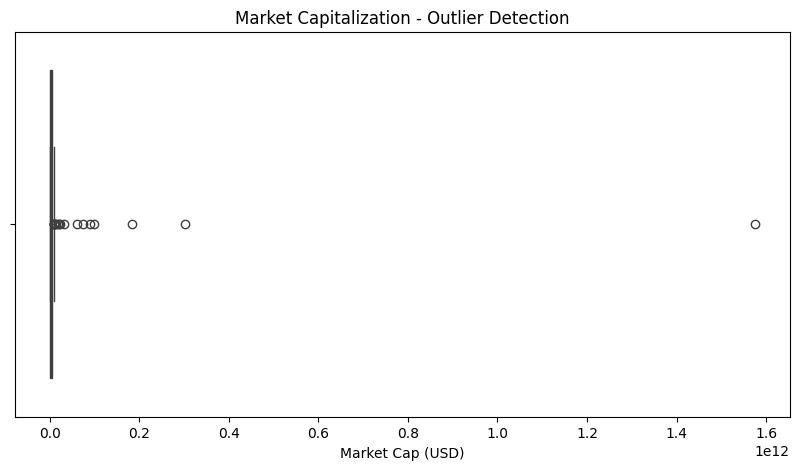

In [37]:
# BOX PLOT - MARKET CAP


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=crypto_clean["market_cap"]
)

plt.title("Market Capitalization - Outlier Detection")
plt.xlabel("Market Cap (USD)")

plt.show()

In [38]:
# IMPORT ISOLATION FOREST


from sklearn.ensemble import IsolationForest

In [39]:
#  PREPARE FEATURES FOR ISOLATION FOREST


isolation_features = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h"
]

crypto_if = crypto_clean[isolation_features].copy()

crypto_if["current_price"] = np.log1p(
    crypto_if["current_price"]
)

crypto_if["market_cap"] = np.log1p(
    crypto_if["market_cap"]
)

crypto_if["total_volume"] = np.log1p(
    crypto_if["total_volume"]
)

crypto_if = crypto_if.replace(
    [np.inf, -np.inf],
    np.nan
)

crypto_if = crypto_if.fillna(
    crypto_if.median()
)

crypto_if.head()

,current_price,market_cap,total_volume,price_change_percentage_24h
0,11.269477,28.084886,24.249400,-0.09490
1,7.817227,26.436734,23.246261,-0.09872
2,0.693050,25.935070,24.693704,0.01711
3,6.606191,25.311975,20.679206,-1.53587
4,0.879627,25.208293,21.716658,-0.02158


In [40]:

# APPLY ISOLATION FOREST


iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

crypto_if["outlier_prediction"] = iso_forest.fit_predict(
    crypto_if[isolation_features]
)

In [41]:
# ADD ISOLATION FOREST RESULTS


crypto_clean["isolation_outlier"] = crypto_if[
    "outlier_prediction"
]

crypto_clean["isolation_outlier"].value_counts()

isolation_outlier
 1    95
-1     5
Name: count, dtype: int64

In [42]:
# INSPECT ISOLATION FOREST OUTLIERS


crypto_clean[
    crypto_clean["isolation_outlier"] == -1
][
    [
        "id",
        "name",
        "current_price",
        "market_cap",
        "total_volume",
        "price_change_percentage_24h"
    ]
]

,id,name,current_price,market_cap,total_volume,price_change_percentage_24h
0,bitcoin,Bitcoin,78391.00,1574385397411,3.399231e+10,-0.09490
1,ethereum,Ethereum,2482.01,302919831138,1.246588e+10,-0.09872
9,zcash,Zcash,1260.64,21340985131,1.329993e+09,7.24867
77,blockchain-capital,Blockchain Capital,106.49,970348700,0.000000e+00,0.25419
84,superstate-short-duration-us-government-securi...,Invesco Short Duration US Government Securitie...,11.21,819745764,0.000000e+00,0.03932


In [43]:
# CREATE OUTLIER FLAG

crypto_clean["is_outlier"] = (
    crypto_clean["isolation_outlier"] == -1
)

crypto_clean["is_outlier"].value_counts()

is_outlier
False    95
True      5
Name: count, dtype: int64

In [44]:
#  REMOVE TEMPORARY OUTLIER COLUMN

crypto_clean = crypto_clean.drop(
    columns=["isolation_outlier"]
)

crypto_clean.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath_date,atl,atl_change_percentage,atl_date,last_updated,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency,is_outlier
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,78391.000000,1574385397411,1,1574390022918,3.399231e+10,79701.000000,...,2025-10-06 10:57:42+00:00,67.810000,1.155060e+05,2013-07-05 16:00:00+00:00,2026-09-09 15:33:20+00:00,-0.4,-0.09490,22.4,2.4,True
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2482.010000,302919831138,2,302919831138,1.246588e+10,2521.510000,...,2025-08-24 11:21:03+00:00,0.432979,5.731418e+05,2015-10-19 16:00:00+00:00,2026-09-09 15:33:20+00:00,-0.3,-0.09872,31.7,4.0,True
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999806,183424669434,3,188890556681,5.300775e+10,0.999995,...,2018-07-23 16:00:00+00:00,0.572521,7.463227e+01,2015-03-01 16:00:00+00:00,2026-09-09 15:33:20+00:00,0.0,0.01711,0.1,0.0,False
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,738.660000,98367349609,4,98367337036,9.568965e+08,757.360000,...,2025-10-13 00:41:24+00:00,0.039818,1.855001e+06,2017-10-18 16:00:00+00:00,2026-09-09 15:33:20+00:00,-0.4,-1.53587,23.9,8.2,False
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.410000,88679393682,5,141313806866,2.700380e+09,1.450000,...,2025-07-17 19:40:53+00:00,0.002686,5.250777e+04,2014-05-21 16:00:00+00:00,2026-09-09 15:33:20+00:00,-0.4,-0.02158,39.0,6.3,False


# CRYPTO FEATURE ENGINEERING

In [45]:
#  CREATE MARKET CAP CATEGORY

def classify_market_cap(market_cap):
    
    if market_cap >= 10_000_000_000:
        return "Large Cap"
    
    elif market_cap >= 1_000_000_000:
        return "Mid Cap"
    
    else:
        return "Small Cap"


crypto_clean["market_cap_category"] = (
    crypto_clean["market_cap"]
    .apply(classify_market_cap)
)

crypto_clean[
    ["name", "market_cap", "market_cap_category"]
].head(10)

,name,market_cap,market_cap_category
0,Bitcoin,1574385397411,Large Cap
1,Ethereum,302919831138,Large Cap
2,Tether,183424669434,Large Cap
3,BNB,98367349609,Large Cap
4,XRP,88679393682,Large Cap
5,USDC,74281931268,Large Cap
6,Solana,60247957536,Large Cap
7,TRON,32108349342,Large Cap
8,Figure Heloc,22974225210,Large Cap
9,Zcash,21340985131,Large Cap


In [46]:

#  CHECK MARKET CAP CATEGORIES


crypto_clean["market_cap_category"].value_counts()

market_cap_category
Mid Cap      60
Small Cap    27
Large Cap    13
Name: count, dtype: int64

In [47]:

# CREATE VOLATILITY SCORE


volatility_columns = [
    "price_change_percentage_1h_in_currency",
    "price_change_percentage_24h_in_currency",
    "price_change_percentage_7d_in_currency",
    "price_change_percentage_30d_in_currency"
]

crypto_clean["volatility_score"] = (
    crypto_clean[volatility_columns]
    .abs()
    .mean(axis=1)
)

crypto_clean[
    ["name", "volatility_score"]
].head(10)

,name,volatility_score
0,Bitcoin,6.323725
1,Ethereum,9.024680
2,Tether,0.029278
3,BNB,8.508967
4,XRP,11.430395
5,USDC,0.001190
6,Solana,10.249840
7,TRON,1.739183
8,Figure Heloc,1.124650
9,Zcash,54.162168


In [48]:

#  CREATE VOLATILITY CATEGORY


def classify_volatility(score):
    
    if score >= 20:
        return "High"
    
    elif score >= 5:
        return "Medium"
    
    else:
        return "Low"


crypto_clean["volatility_category"] = (
    crypto_clean["volatility_score"]
    .apply(classify_volatility)
)

crypto_clean[
    [
        "name",
        "volatility_score",
        "volatility_category"
    ]
].head(10)

,name,volatility_score,volatility_category
0,Bitcoin,6.323725,Medium
1,Ethereum,9.024680,Medium
2,Tether,0.029278,Low
3,BNB,8.508967,Medium
4,XRP,11.430395,Medium
5,USDC,0.001190,Low
6,Solana,10.249840,Medium
7,TRON,1.739183,Low
8,Figure Heloc,1.124650,Low
9,Zcash,54.162168,High


In [49]:

#  CREATE SUPPLY RATIO


crypto_clean["supply_ratio"] = (
    crypto_clean["circulating_supply"] /
    crypto_clean["total_supply"]
)

crypto_clean[
    [
        "name",
        "circulating_supply",
        "total_supply",
        "supply_ratio"
    ]
].head(10)

,name,circulating_supply,total_supply,supply_ratio
0,Bitcoin,2.008185e+07,2.008191e+07,0.999997
1,Ethereum,1.220326e+08,1.220326e+08,1.000000
2,Tether,1.834602e+11,1.889271e+11,0.971063
3,BNB,1.331613e+08,1.331613e+08,1.000000
4,XRP,6.274450e+10,9.998563e+10,0.627535
5,USDC,7.429023e+10,7.429064e+10,0.999994
6,Solana,5.862504e+08,6.337367e+08,0.925069
7,TRON,9.494200e+10,9.494200e+10,1.000000
8,Figure Heloc,2.229061e+10,2.237903e+10,0.996049
9,Zcash,1.692187e+07,1.692318e+07,0.999922


In [50]:

#  VALIDATE SUPPLY RATIO


print(
    "Supply ratios below 0:",
    (crypto_clean["supply_ratio"] < 0).sum()
)

print(
    "Supply ratios above 1:",
    (crypto_clean["supply_ratio"] > 1).sum()
)

print(
    "Missing supply ratios:",
    crypto_clean["supply_ratio"].isnull().sum()
)

Supply ratios below 0: 0
Supply ratios above 1: 4
Missing supply ratios: 0


In [51]:
#  CREATE 24H PRICE CHANGE CATEGORY


def classify_price_change(change):
    
    if change < -5:
        return "Strong Loss"
    
    elif change < 0:
        return "Loss"
    
    elif change == 0:
        return "No Change"
    
    elif change <= 5:
        return "Gain"
    
    else:
        return "Strong Gain"


crypto_clean["price_change_category"] = (
    crypto_clean["price_change_percentage_24h"]
    .apply(classify_price_change)
)

crypto_clean[
    [
        "name",
        "price_change_percentage_24h",
        "price_change_category"
    ]
].head(10)

,name,price_change_percentage_24h,price_change_category
0,Bitcoin,-0.09490,Loss
1,Ethereum,-0.09872,Loss
2,Tether,0.01711,Gain
3,BNB,-1.53587,Loss
4,XRP,-0.02158,Loss
5,USDC,0.00476,Gain
6,Solana,-0.59936,Loss
7,TRON,-0.25673,Loss
8,Figure Heloc,0.19860,Gain
9,Zcash,7.24867,Strong Gain


In [52]:
#  CHECK ENGINEERED FEATURES


engineered_columns = [
    "market_cap_category",
    "volatility_score",
    "volatility_category",
    "supply_ratio",
    "price_change_category"
]

crypto_clean[engineered_columns].head(10)

,market_cap_category,volatility_score,volatility_category,supply_ratio,price_change_category
0,Large Cap,6.323725,Medium,0.999997,Loss
1,Large Cap,9.024680,Medium,1.000000,Loss
2,Large Cap,0.029278,Low,0.971063,Gain
3,Large Cap,8.508967,Medium,1.000000,Loss
4,Large Cap,11.430395,Medium,0.627535,Loss
5,Large Cap,0.001190,Low,0.999994,Gain
6,Large Cap,10.249840,Medium,0.925069,Loss
7,Large Cap,1.739183,Low,1.000000,Loss
8,Large Cap,1.124650,Low,0.996049,Gain
9,Large Cap,54.162168,High,0.999922,Strong Gain


In [53]:
#  FEATURE ENGINEERING SUMMARY


print("New Features Created:")
print()

for column in engineered_columns:
    print("-", column)

New Features Created:

- market_cap_category
- volatility_score
- volatility_category
- supply_ratio
- price_change_category


In [54]:
# CHECK FINAL CRYPTO DATASET


print("Shape:", crypto_clean.shape)

print("\nColumns:")
print(crypto_clean.columns.tolist())

print("\nMissing Values:")
print(
    crypto_clean.isnull().sum()[
        crypto_clean.isnull().sum() > 0
    ]
)

Shape: (100, 35)

Columns:
['id', 'symbol', 'name', 'image', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated', 'price_change_percentage_1h_in_currency', 'price_change_percentage_24h_in_currency', 'price_change_percentage_30d_in_currency', 'price_change_percentage_7d_in_currency', 'is_outlier', 'market_cap_category', 'volatility_score', 'volatility_category', 'supply_ratio', 'price_change_category']

Missing Values:
max_supply                                 47
price_change_percentage_30d_in_currency     1
price_change_percentage_7d_in_currency      1
dtype: int64


# EXPLORATORY DATA ANALYSIS

In [55]:

# Import Visualization Libraries


import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries imported successfully!")

Visualization libraries imported successfully!


In [56]:

# Check Dataset Before EDA

print("Shape:", crypto_clean.shape)

print("\nColumns:")
print(crypto_clean.columns.tolist())

print("\nData Types:")
print(crypto_clean.dtypes)

Shape: (100, 35)

Columns:
['id', 'symbol', 'name', 'image', 'current_price', 'market_cap', 'market_cap_rank', 'fully_diluted_valuation', 'total_volume', 'high_24h', 'low_24h', 'price_change_24h', 'price_change_percentage_24h', 'market_cap_change_24h', 'market_cap_change_percentage_24h', 'circulating_supply', 'total_supply', 'max_supply', 'ath', 'ath_change_percentage', 'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'last_updated', 'price_change_percentage_1h_in_currency', 'price_change_percentage_24h_in_currency', 'price_change_percentage_30d_in_currency', 'price_change_percentage_7d_in_currency', 'is_outlier', 'market_cap_category', 'volatility_score', 'volatility_category', 'supply_ratio', 'price_change_category']

Data Types:
id                                                      object
symbol                                                  object
name                                                    object
image                                                   object

Market Cap Distribution

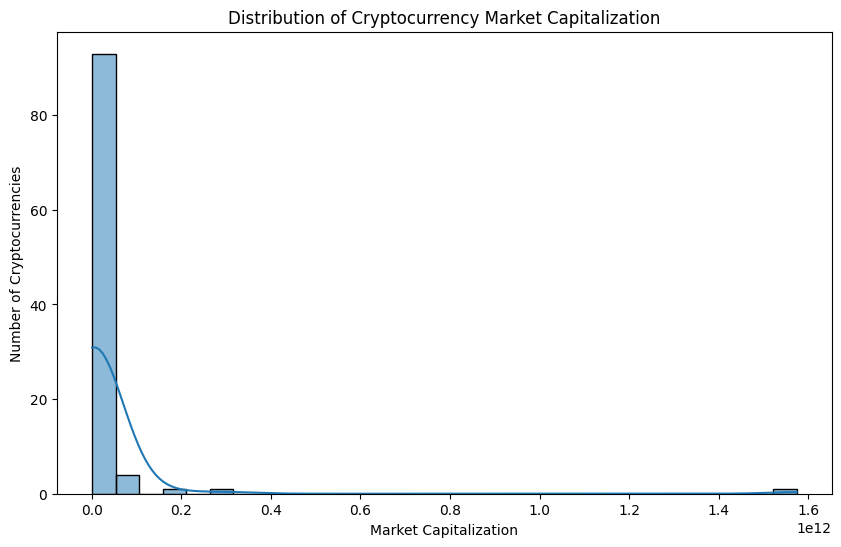

In [57]:

# Market Capitalization Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    crypto_clean["market_cap"],
    bins=30,
    kde=True
)

plt.title("Distribution of Cryptocurrency Market Capitalization")
plt.xlabel("Market Capitalization")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

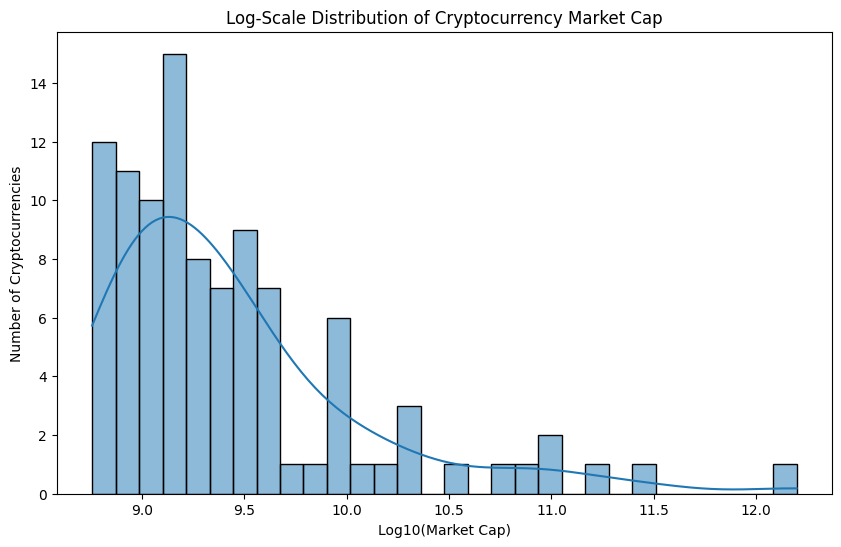

In [58]:

# Log-Scale Market Cap Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    np.log10(crypto_clean["market_cap"]),
    bins=30,
    kde=True
)

plt.title("Log-Scale Distribution of Cryptocurrency Market Cap")
plt.xlabel("Log10(Market Cap)")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Price Distribution

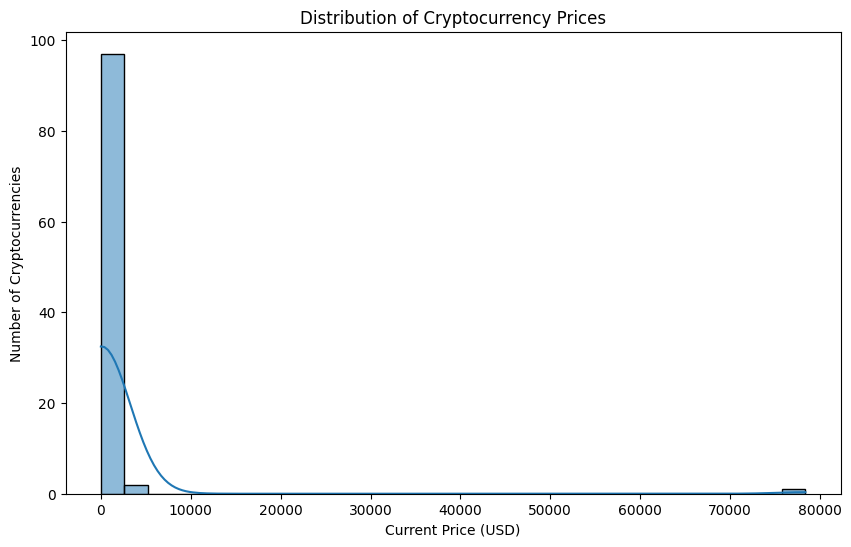

In [59]:

# Cryptocurrency Price Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    crypto_clean["current_price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Cryptocurrency Prices")
plt.xlabel("Current Price (USD)")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

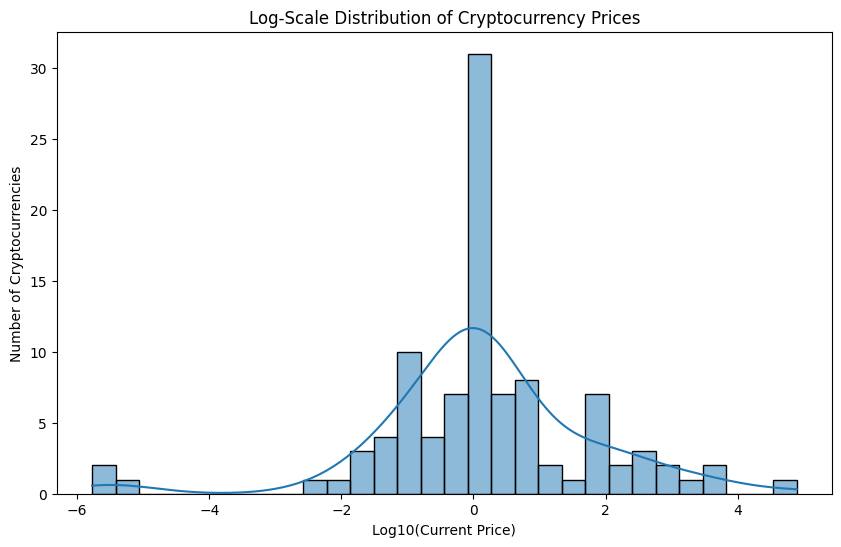

In [60]:

# Log-Scale Price Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    np.log10(crypto_clean["current_price"]),
    bins=30,
    kde=True
)

plt.title("Log-Scale Distribution of Cryptocurrency Prices")
plt.xlabel("Log10(Current Price)")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Top Cryptocurrencies by Market Cap

In [61]:

# Top 10 Cryptocurrencies by Market Cap


top_market_cap = (
    crypto_clean
    .sort_values("market_cap", ascending=False)
    [["name", "symbol", "market_cap"]]
    .head(10)
)

top_market_cap

,name,symbol,market_cap
0,Bitcoin,btc,1574385397411
1,Ethereum,eth,302919831138
2,Tether,usdt,183424669434
3,BNB,bnb,98367349609
4,XRP,xrp,88679393682
5,USDC,usdc,74281931268
6,Solana,sol,60247957536
7,TRON,trx,32108349342
8,Figure Heloc,figr_heloc,22974225210
9,Zcash,zec,21340985131


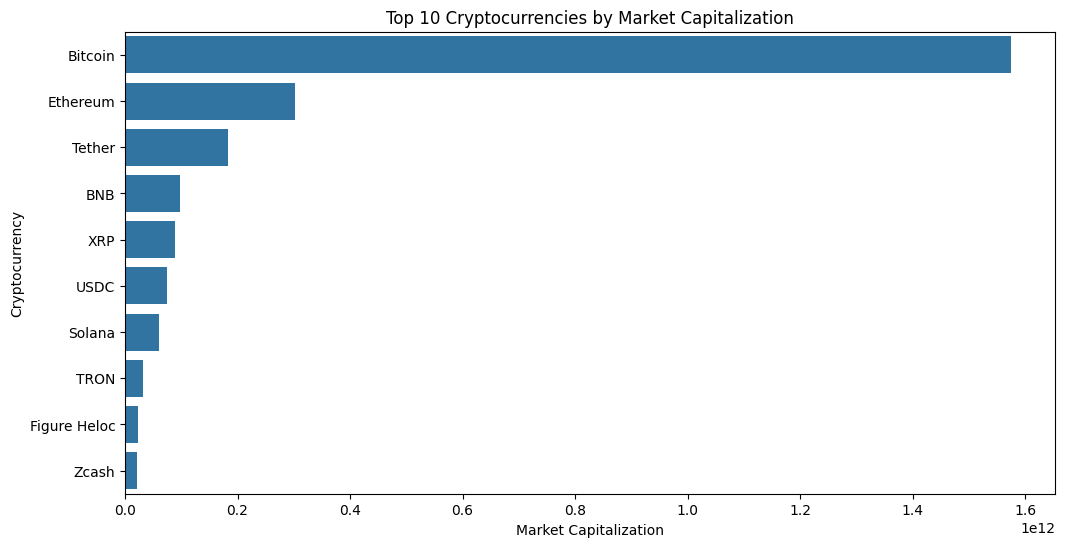

In [62]:

# Top 10 Market Cap Visualization


plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_market_cap,
    x="market_cap",
    y="name"
)

plt.title("Top 10 Cryptocurrencies by Market Capitalization")
plt.xlabel("Market Capitalization")
plt.ylabel("Cryptocurrency")

plt.show()

Trading Volume Analysis

In [63]:

# Top 10 Cryptocurrencies by Trading Volume


top_volume = (
    crypto_clean
    .sort_values("total_volume", ascending=False)
    [["name", "symbol", "total_volume"]]
    .head(10)
)

top_volume

,name,symbol,total_volume
2,Tether,usdt,5.300775e+10
0,Bitcoin,btc,3.399231e+10
5,USDC,usdc,1.522636e+10
1,Ethereum,eth,1.246588e+10
16,Chainlink,link,6.930095e+09
6,Solana,sol,3.017973e+09
4,XRP,xrp,2.700380e+09
9,Zcash,zec,1.329993e+09
31,Global Dollar,usdg,1.266648e+09
10,Hyperliquid,hype,1.063279e+09


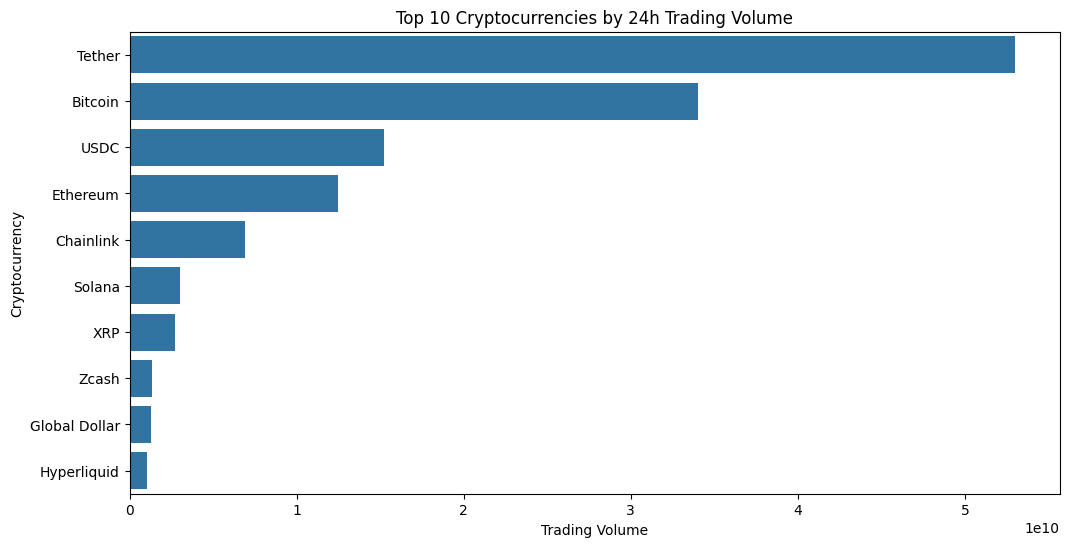

In [64]:

# Trading Volume Visualization


plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_volume,
    x="total_volume",
    y="name"
)

plt.title("Top 10 Cryptocurrencies by 24h Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Cryptocurrency")

plt.show()

Market Cap vs Trading Volume

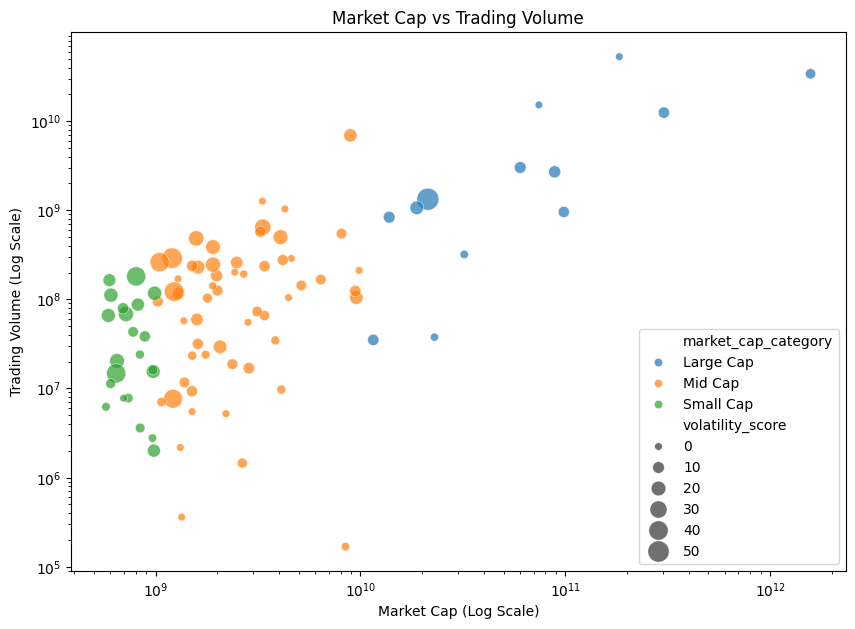

In [65]:

# Market Cap vs Trading Volume


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=crypto_clean,
    x="market_cap",
    y="total_volume",
    hue="market_cap_category",
    size="volatility_score",
    sizes=(30, 250),
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("Market Cap vs Trading Volume")
plt.xlabel("Market Cap (Log Scale)")
plt.ylabel("Trading Volume (Log Scale)")

plt.show()

24h Price Change Analysis

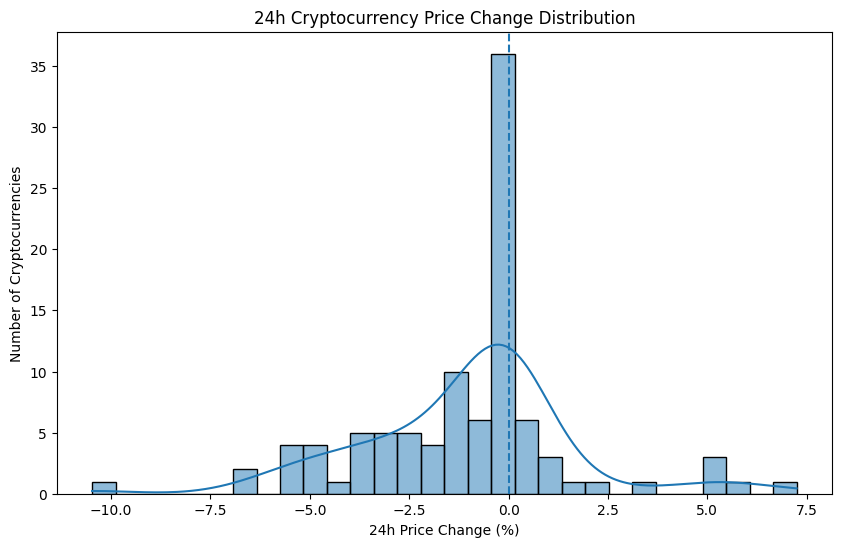

In [66]:

# 24h Price Change Distribution


plt.figure(figsize=(10, 6))

sns.histplot(
    crypto_clean["price_change_percentage_24h"],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("24h Cryptocurrency Price Change Distribution")
plt.xlabel("24h Price Change (%)")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Price Change Categories

In [67]:

# Price Change Category Counts

price_change_counts = (
    crypto_clean["price_change_category"]
    .value_counts()
)

price_change_counts

price_change_category
Loss           62
Gain           24
Strong Loss     7
Strong Gain     5
No Change       2
Name: count, dtype: int64

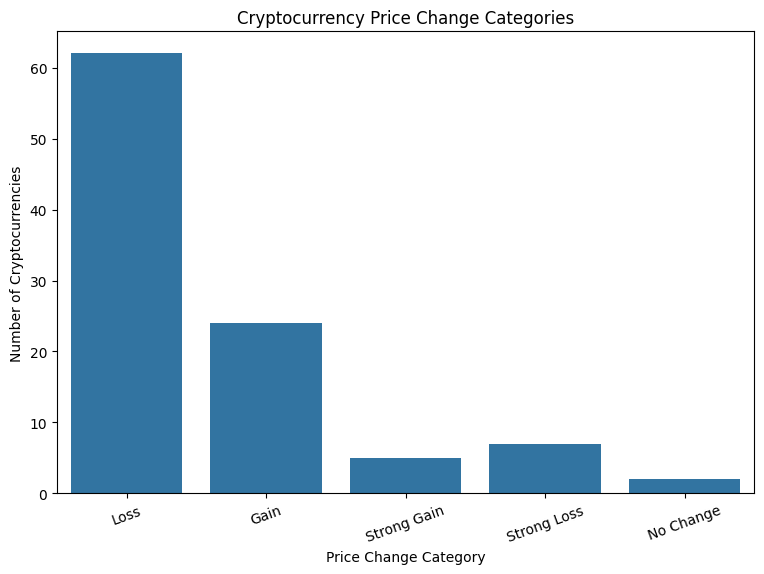

In [68]:

# Price Change Category Visualization


plt.figure(figsize=(9, 6))

sns.countplot(
    data=crypto_clean,
    x="price_change_category"
)

plt.title("Cryptocurrency Price Change Categories")
plt.xlabel("Price Change Category")
plt.ylabel("Number of Cryptocurrencies")

plt.xticks(rotation=20)

plt.show()

Volatility Analysis

In [69]:

# Volatility Category Counts


volatility_counts = (
    crypto_clean["volatility_category"]
    .value_counts()
)

volatility_counts

volatility_category
Medium    48
Low       39
High      13
Name: count, dtype: int64

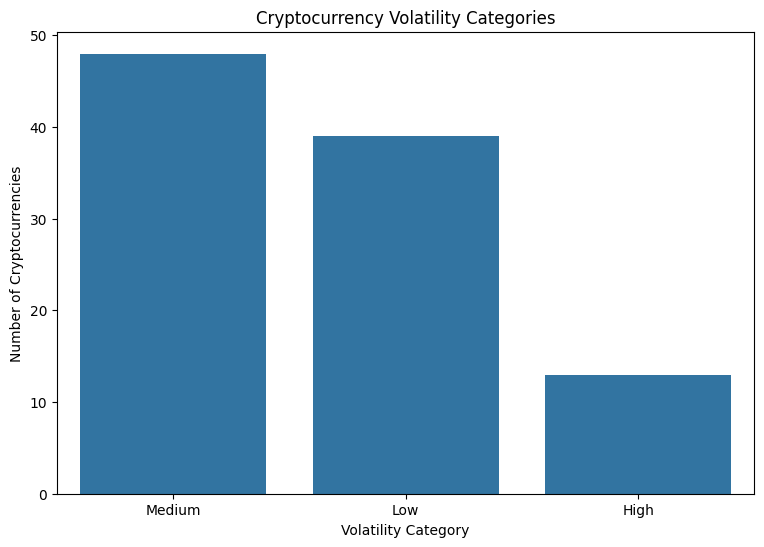

In [70]:

# Volatility Category Visualization


plt.figure(figsize=(9, 6))

sns.countplot(
    data=crypto_clean,
    x="volatility_category"
)

plt.title("Cryptocurrency Volatility Categories")
plt.xlabel("Volatility Category")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Market Cap Category Analysis

In [71]:

# Market Cap Category Distribution


market_cap_counts = (
    crypto_clean["market_cap_category"]
    .value_counts()
)

market_cap_counts

market_cap_category
Mid Cap      60
Small Cap    27
Large Cap    13
Name: count, dtype: int64

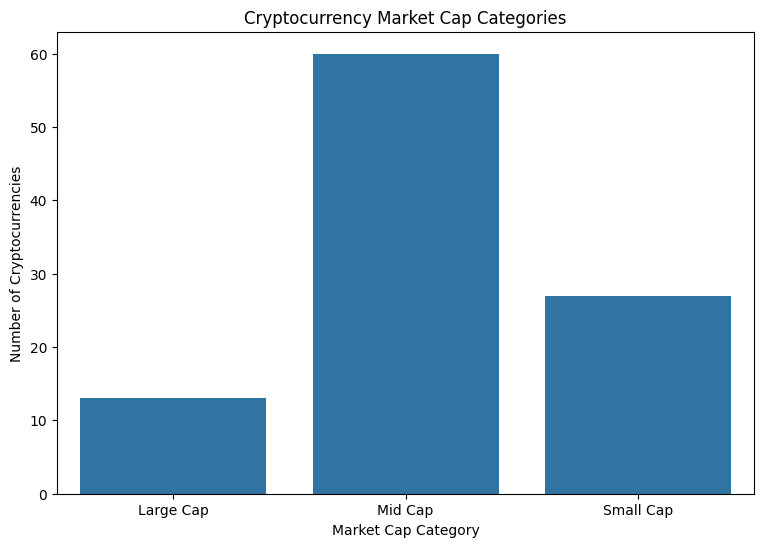

In [72]:

# Market Cap Category Visualization


plt.figure(figsize=(9, 6))

sns.countplot(
    data=crypto_clean,
    x="market_cap_category"
)

plt.title("Cryptocurrency Market Cap Categories")
plt.xlabel("Market Cap Category")
plt.ylabel("Number of Cryptocurrencies")

plt.show()

Volatility vs Market Cap

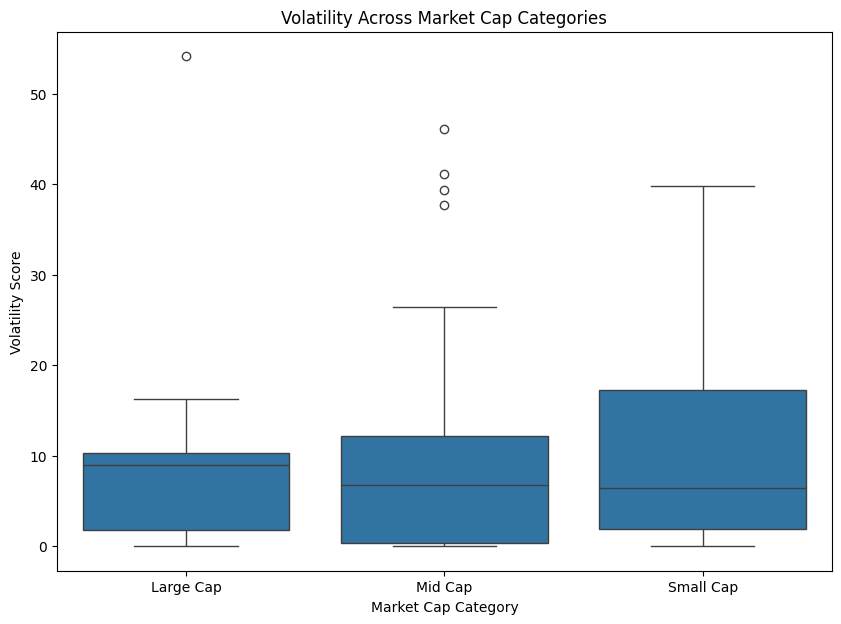

In [73]:

# Volatility vs Market Cap

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=crypto_clean,
    x="market_cap_category",
    y="volatility_score"
)

plt.title("Volatility Across Market Cap Categories")
plt.xlabel("Market Cap Category")
plt.ylabel("Volatility Score")

plt.show()

Correlation Analysis

In [74]:

# Select Important Numeric Features


correlation_columns = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h",
    "price_change_percentage_1h_in_currency",
    "price_change_percentage_7d_in_currency",
    "price_change_percentage_30d_in_currency",
    "volatility_score",
    "supply_ratio"
]

correlation_matrix = (
    crypto_clean[correlation_columns]
    .corr()
)

correlation_matrix

,current_price,market_cap,total_volume,price_change_percentage_24h,price_change_percentage_1h_in_currency,price_change_percentage_7d_in_currency,price_change_percentage_30d_in_currency,volatility_score,supply_ratio
current_price,1.000000,0.973860,0.505462,0.046266,-0.014182,-0.048466,-0.009405,-0.032689,0.079901
market_cap,0.973860,1.000000,0.624643,0.053947,-0.019481,-0.063645,-0.011721,-0.042614,0.094400
total_volume,0.505462,0.624643,1.000000,0.057320,-0.022417,-0.088585,-0.060805,-0.089841,0.109348
price_change_percentage_24h,0.046266,0.053947,0.057320,1.000000,0.055117,0.177025,0.192330,0.164894,0.080249
price_change_percentage_1h_in_currency,-0.014182,-0.019481,-0.022417,0.055117,1.000000,-0.087900,-0.043955,0.264148,-0.186806
price_change_percentage_7d_in_currency,-0.048466,-0.063645,-0.088585,0.177025,-0.087900,1.000000,0.727764,0.851842,-0.136704
price_change_percentage_30d_in_currency,-0.009405,-0.011721,-0.060805,0.192330,-0.043955,0.727764,1.000000,0.966611,-0.318323
volatility_score,-0.032689,-0.042614,-0.089841,0.164894,0.264148,0.851842,0.966611,1.000000,-0.340635
supply_ratio,0.079901,0.094400,0.109348,0.080249,-0.186806,-0.136704,-0.318323,-0.340635,1.000000


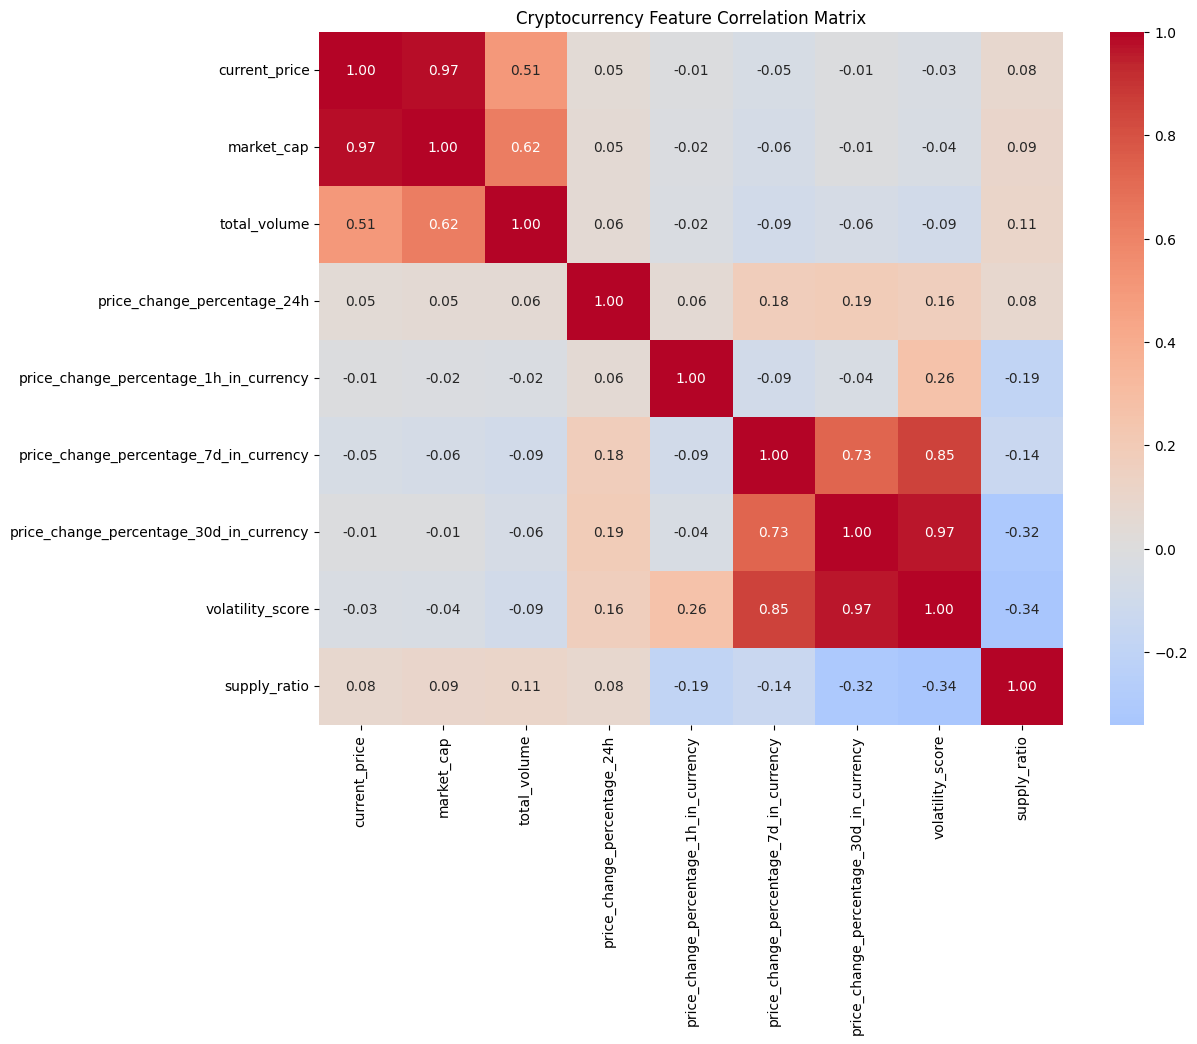

In [75]:

# Correlation Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Cryptocurrency Feature Correlation Matrix")

plt.show()

Most Volatile Cryptocurrencies

In [76]:

# Top 10 Most Volatile Cryptocurrencies


top_volatile = (
    crypto_clean
    .sort_values("volatility_score", ascending=False)
    [[
        "name",
        "symbol",
        "volatility_score",
        "volatility_category",
        "price_change_percentage_24h"
    ]]
    .head(10)
)

top_volatile

,name,symbol,volatility_score,volatility_category,price_change_percentage_24h
9,Zcash,zec,54.162168,High,7.24867
69,Venice Token,vvv,46.110467,High,5.14187
67,Lighter,lit,41.120020,High,5.18008
94,Hunter Biden's Laptop,laptop,39.828365,High,-0.25673
85,Dash,dash,39.454150,High,-0.41660
71,Arbitrum,arb,39.368090,High,-6.57236
68,Bitway,btw,37.771260,High,-0.78504
30,NEAR Protocol,near,26.453753,High,6.01501
55,Ethena,ena,22.547010,High,-3.18804
89,PancakeSwap,cake,21.820590,High,-1.88236


Highest 24h Gainers and Losers

In [77]:

# Top 10 24h Gainers

top_gainers = (
    crypto_clean
    .sort_values(
        "price_change_percentage_24h",
        ascending=False
    )
    [["name", "symbol", "price_change_percentage_24h"]]
    .head(10)
)

top_gainers

,name,symbol,price_change_percentage_24h
9,Zcash,zec,7.24867
30,NEAR Protocol,near,6.01501
48,Pump.fun,pump,5.22702
67,Lighter,lit,5.18008
69,Venice Token,vvv,5.14187
73,Cosmos Hub,atom,3.63620
83,Jupiter,jup,2.25799
14,WhiteBIT Coin,wbt,1.50303
10,Hyperliquid,hype,1.20377
98,Ether.fi,ethfi,1.15353


In [78]:

# Top 10 24h Losers

top_losers = (
    crypto_clean
    .sort_values(
        "price_change_percentage_24h",
        ascending=True
    )
    [["name", "symbol", "price_change_percentage_24h"]]
    .head(10)
)
top_losers


,name,symbol,price_change_percentage_24h
52,Worldcoin,wld,-10.47778
71,Arbitrum,arb,-6.57236
64,Ethereum Classic,etc,-6.34666
54,Internet Computer,icp,-5.52427
82,JUST,jst,-5.50932
16,Chainlink,link,-5.40813
18,Cardano,ada,-5.35844
26,Uniswap,uni,-4.94990
95,Injective,inj,-4.75571
59,Sky,sky,-4.74996


In [79]:

# Save Cleaned Crypto Dataset


crypto_clean.to_csv(
    "../data/processed/crypto_clean.csv",
    index=False
)

print("Cleaned crypto dataset saved successfully!")

Cleaned crypto dataset saved successfully!


In [80]:

# Verify Cleaned Crypto Dataset


crypto_check = pd.read_csv(
    "../data/processed/crypto_clean.csv"
)

print("Shape:", crypto_check.shape)

crypto_check.head()

Shape: (100, 35)


,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,price_change_percentage_1h_in_currency,price_change_percentage_24h_in_currency,price_change_percentage_30d_in_currency,price_change_percentage_7d_in_currency,is_outlier,market_cap_category,volatility_score,volatility_category,supply_ratio,price_change_category
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,78391.000000,1574385397411,1,1574390022918,3.399231e+10,79701.000000,...,-0.4,-0.09490,22.4,2.4,True,Large Cap,6.323725,Medium,0.999997,Loss
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2482.010000,302919831138,2,302919831138,1.246588e+10,2521.510000,...,-0.3,-0.09872,31.7,4.0,True,Large Cap,9.024680,Medium,1.000000,Loss
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999806,183424669434,3,188890556681,5.300775e+10,0.999995,...,0.0,0.01711,0.1,0.0,False,Large Cap,0.029278,Low,0.971063,Gain
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,738.660000,98367349609,4,98367337036,9.568965e+08,757.360000,...,-0.4,-1.53587,23.9,8.2,False,Large Cap,8.508967,Medium,1.000000,Loss
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.410000,88679393682,5,141313806866,2.700380e+09,1.450000,...,-0.4,-0.02158,39.0,6.3,False,Large Cap,11.430395,Medium,0.627535,Loss


# DATA QUALITY & PIPELINE VALIDATION

In [81]:

# Dataset Validation Summary


print("DATASET VALIDATION")

print("\nShape:")
print(crypto_clean.shape)

print("\nDuplicate IDs:")
print(crypto_clean["id"].duplicated().sum())

print("\nDuplicate Symbols:")
print(crypto_clean["symbol"].duplicated().sum())

print("\nMissing Values:")
print(crypto_clean.isnull().sum()[crypto_clean.isnull().sum() > 0])

print("\nCurrent Price <= 0:")
print((crypto_clean["current_price"] <= 0).sum())

print("\nNegative Market Cap:")
print((crypto_clean["market_cap"] < 0).sum())

print("\nNegative Trading Volume:")
print((crypto_clean["total_volume"] < 0).sum())

DATASET VALIDATION

Shape:
(100, 35)

Duplicate IDs:
0

Duplicate Symbols:
0

Missing Values:
max_supply                                 47
price_change_percentage_30d_in_currency     1
price_change_percentage_7d_in_currency      1
dtype: int64

Current Price <= 0:
0

Negative Market Cap:
0

Negative Trading Volume:
0


In [82]:

# Validate Numeric Columns


numeric_validation_columns = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h",
    "volatility_score",
    "supply_ratio"
]

for column in numeric_validation_columns:

    print(
        column,
        "->",
        crypto_clean[column].dtype
    )

current_price -> float64
market_cap -> int64
total_volume -> float64
price_change_percentage_24h -> float64
volatility_score -> float64
supply_ratio -> float64


In [83]:

# Validate 24h Price Relationships


invalid_low_price = (
    crypto_clean["low_24h"] >
    crypto_clean["current_price"]
).sum()

invalid_high_price = (
    crypto_clean["current_price"] >
    crypto_clean["high_24h"]
).sum()

print("Low price > current price:", invalid_low_price)
print("Current price > high price:", invalid_high_price)

Low price > current price: 31
Current price > high price: 0


In [84]:

# Validate Supply Ratio


invalid_supply_ratio = crypto_clean[
    (crypto_clean["supply_ratio"] < 0) |
    (crypto_clean["supply_ratio"] > 1)
]

print("Invalid supply ratio records:")
print(len(invalid_supply_ratio))

invalid_supply_ratio[
    [
        "name",
        "symbol",
        "circulating_supply",
        "total_supply",
        "supply_ratio"
    ]
]

Invalid supply ratio records:
4


,name,symbol,circulating_supply,total_supply,supply_ratio
1,Ethereum,eth,1.220326e+08,1.220326e+08,1.000000
3,BNB,bnb,1.331613e+08,1.331613e+08,1.000000
35,PayPal USD,pyusd,2.824063e+09,2.824063e+09,1.000000
58,USDD,usdd,1.509067e+09,1.508816e+09,1.000167


In [85]:

# Validate Market Cap Categories


valid_market_cap_categories = [
    "Large Cap",
    "Mid Cap",
    "Small Cap"
]

invalid_market_cap_categories = crypto_clean[
    ~crypto_clean["market_cap_category"].isin(
        valid_market_cap_categories
    )
]

print(
    "Invalid market cap categories:",
    len(invalid_market_cap_categories)
)

Invalid market cap categories: 0


In [86]:

# Validate Volatility Categories


valid_volatility_categories = [
    "Low",
    "Medium",
    "High"
]

invalid_volatility_categories = crypto_clean[
    ~crypto_clean["volatility_category"].isin(
        valid_volatility_categories
    )
]

print(
    "Invalid volatility categories:",
    len(invalid_volatility_categories)
)

Invalid volatility categories: 0


In [87]:

# Validate Price Change Categories


valid_price_categories = [
    "Strong Loss",
    "Loss",
    "No Change",
    "Gain",
    "Strong Gain"
]

invalid_price_categories = crypto_clean[
    ~crypto_clean["price_change_category"].isin(
        valid_price_categories
    )
]

print(
    "Invalid price change categories:",
    len(invalid_price_categories)
)

Invalid price change categories: 0


In [88]:

# Check Infinite Values


numeric_data = crypto_clean.select_dtypes(
    include=np.number
)

infinite_values = np.isinf(numeric_data).sum()

print(
    "Infinite values:",
    infinite_values[infinite_values > 0]
)

Infinite values: Series([], dtype: int64)


In [89]:

# Final Missing Value Report


missing_report = (
    crypto_clean
    .isnull()
    .sum()
    .reset_index()
)

missing_report.columns = [
    "column",
    "missing_count"
]

missing_report["missing_percentage"] = (
    missing_report["missing_count"]
    / len(crypto_clean)
    * 100
)

missing_report = missing_report[
    missing_report["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

missing_report

,column,missing_count,missing_percentage
17,max_supply,47,47.0
27,price_change_percentage_30d_in_currency,1,1.0
28,price_change_percentage_7d_in_currency,1,1.0


In [90]:

# Pipeline Validation Function


def validate_crypto_dataset(df):

    validation_results = {}

    # Basic checks

    validation_results["row_count"] = len(df)

    validation_results["duplicate_ids"] = (
        df["id"].duplicated().sum()
    )

    validation_results["duplicate_symbols"] = (
        df["symbol"].duplicated().sum()
    )

   
    # Price checks
   

    validation_results["invalid_prices"] = (
        (df["current_price"] <= 0).sum()
    )

    
    # Market cap checks
  

    validation_results["negative_market_cap"] = (
        (df["market_cap"] < 0).sum()
    )

    
    # Volume checks
   

    validation_results["negative_volume"] = (
        (df["total_volume"] < 0).sum()
    )

    
    # Infinite value check
   

    numeric_data = df.select_dtypes(
        include=np.number
    )

    validation_results["infinite_values"] = (
        np.isinf(numeric_data).sum().sum()
    )

    
    # Return results
   

    return validation_results

In [91]:

# Run Pipeline Validation


validation_results = validate_crypto_dataset(
    crypto_clean
)

validation_results

{'row_count': 100,
 'duplicate_ids': np.int64(0),
 'duplicate_symbols': np.int64(0),
 'invalid_prices': np.int64(0),
 'negative_market_cap': np.int64(0),
 'negative_volume': np.int64(0),
 'infinite_values': np.int64(0)}

In [92]:

# Pipeline Quality Gate


quality_checks = {
    "No duplicate IDs":
        validation_results["duplicate_ids"] == 0,

    "No duplicate symbols":
        validation_results["duplicate_symbols"] == 0,

    "No invalid prices":
        validation_results["invalid_prices"] == 0,

    "No negative market cap":
        validation_results["negative_market_cap"] == 0,

    "No negative volume":
        validation_results["negative_volume"] == 0,

    "No infinite values":
        validation_results["infinite_values"] == 0
}

for check, passed in quality_checks.items():

    status = "PASS" if passed else "FAIL"

    print(f"{status}: {check}")

PASS: No duplicate IDs
PASS: No duplicate symbols
PASS: No invalid prices
PASS: No negative market cap
PASS: No negative volume
PASS: No infinite values


In [93]:

# Final Pipeline Quality Gate


pipeline_passed = all(
    quality_checks.values()
)

if pipeline_passed:  
    print("PIPELINE VALIDATION PASSED")
    
else:
    print("PIPELINE VALIDATION FAILED")
    

PIPELINE VALIDATION PASSED


# BOOKS TO SCRAPE DATA COLLECTION

In [94]:

# STEP 9 — BOOKS TO SCRAPE DATA COLLECTION


import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np

In [95]:
url = "https://books.toscrape.com/"

In [96]:
response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [97]:

# Parse HTML Using BeautifulSoup


soup = BeautifulSoup(
    response.text,
    "html.parser"
)

print("HTML parsed successfully!")

HTML parsed successfully!


In [98]:

# Find Book Elements


books = soup.find_all(
    "article",
    class_="product_pod"
)

print("Books found:", len(books))

Books found: 20


In [99]:

# Inspect First Book

first_book = books[0]

print(first_book.prettify()[:3000])

<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   Â£51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



In [100]:

# Scrape All Books from Books to Scrape


base_url = "https://books.toscrape.com/catalogue/page-{}.html"

books_data = []

for page in range(1, 51):

    url = base_url.format(page)

    response = requests.get(url)

    if response.status_code != 200:
        print(f"Page {page} failed")
        continue

    soup = BeautifulSoup(response.text,"html.parser")

    books = soup.find_all("article",class_="product_pod")

    for book in books:

        # Book title

        title = book.h3.a.get("title")

       
        # Price
       
        price = book.find("p",class_="price_color").text.strip()

      
        # Rating

        rating_class = book.find("p",class_="star-rating").get("class")

        rating = rating_class[1]

        # Availability
        

        availability = book.find("p",class_="instock availability").text.strip()

        
        # Book URL

        relative_url = book.h3.a.get("href")

        book_url = (
            "https://books.toscrape.com/catalogue/"
            + relative_url.replace("../", "")
        )

        
        # Store record

        books_data.append({
            "title": title,
            "price": price,
            "rating": rating,
            "availability": availability,
            "book_url": book_url
        })

print("Total books scraped:", len(books_data))

Total books scraped: 1000


In [101]:

# Create Books Raw DataFrame

books_raw = pd.DataFrame(books_data)

print("Shape:", books_raw.shape)

books_raw.head()

Shape: (1000, 5)


,title,price,rating,availability,book_url
0,A Light in the Attic,Â£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [102]:

# Books Dataset Information


books_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         1000 non-null   object
 1   price         1000 non-null   object
 2   rating        1000 non-null   object
 3   availability  1000 non-null   object
 4   book_url      1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB


In [103]:

# Books Dataset Columns


print(books_raw.columns.tolist())

['title', 'price', 'rating', 'availability', 'book_url']


In [104]:

# Missing Values


books_raw.isnull().sum()

title           0
price           0
rating          0
availability    0
book_url        0
dtype: int64

In [105]:

# Duplicate Book Titles


duplicate_titles = books_raw["title"].duplicated().sum()

print("Duplicate titles:", duplicate_titles)

Duplicate titles: 1


In [106]:

# Inspect Unique Rating Values


print("Ratings:")
print(books_raw["rating"].value_counts())

print("\nAvailability:")
print(books_raw["availability"].value_counts().head(10))

print("\nPrice examples:")
print(books_raw["price"].head(10))

Ratings:
rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64

Availability:
availability
In stock    1000
Name: count, dtype: int64

Price examples:
0    Â£51.77
1    Â£53.74
2    Â£50.10
3    Â£47.82
4    Â£54.23
5    Â£22.65
6    Â£33.34
7    Â£17.93
8    Â£22.60
9    Â£52.15
Name: price, dtype: object


In [107]:
# Save Raw Books Dataset

books_raw.to_csv("../data/raw/books_raw.csv",index=False)

print("Raw books dataset saved successfully!")

Raw books dataset saved successfully!


In [108]:
# BOOKS DATA CLEANING


# Create cleaning copy
books_clean = books_raw.copy()

# Clean Title

books_clean["title"] = (
    books_clean["title"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)


# Clean Price


books_clean["price"] = (
    books_clean["price"]
    .astype(str)
    .str.replace("Â£", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
)

books_clean["price"] = pd.to_numeric(
    books_clean["price"],
    errors="coerce"
)

# Convert Rating


rating_mapping = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_clean["rating"] = (
    books_clean["rating"]
    .map(rating_mapping)
)


# Clean Availability


books_clean["availability"] = (
    books_clean["availability"]
    .astype(str)
    .str.strip()
)


# Create Stock Status


books_clean["stock_status"] = (
    books_clean["availability"]
    .str.lower()
    .apply(
        lambda x: "In Stock"
        if "in stock" in x
        else "Out of Stock"
    )
)

print("Books cleaning completed!")
print("Shape:", books_clean.shape)

Books cleaning completed!
Shape: (1000, 6)


In [109]:
# Check Clean Books Dataset


print(books_clean.dtypes)

print("\nMissing Values:")
print(books_clean.isnull().sum())

print("\nDuplicate Titles:")
print(books_clean["title"].duplicated().sum())

books_clean.head()

title            object
price           float64
rating            int64
availability     object
book_url         object
stock_status     object
dtype: object

Missing Values:
title           0
price           0
rating          0
availability    0
book_url        0
stock_status    0
dtype: int64

Duplicate Titles:
1


,title,price,rating,availability,book_url,stock_status
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...,In Stock
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...,In Stock
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...,In Stock
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...,In Stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...,In Stock


# BOOKS DATA CLEANING

In [110]:

# Create Books Cleaning Copy


books_clean = books_raw.copy()

print("Cleaning copy created successfully!")
print("Shape:", books_clean.shape)

Cleaning copy created successfully!
Shape: (1000, 5)


In [111]:

# Clean Book Titles


books_clean["title"] = (
    books_clean["title"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("Title cleaning completed!")

Title cleaning completed!


In [112]:
books_clean["title"].head()

0                     A Light in the Attic
1                       Tipping the Velvet
2                               Soumission
3                            Sharp Objects
4    Sapiens: A Brief History of Humankind
Name: title, dtype: object

In [113]:
# Clean Book Price


books_clean["price"] = (
    books_clean["price"]
    .astype(str)
    .str.replace("Â£", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
)

books_clean["price"] = pd.to_numeric(
    books_clean["price"],
    errors="coerce"
)

print("Price cleaning completed!")
print(books_clean["price"].head())
print("\nData type:", books_clean["price"].dtype)

Price cleaning completed!
0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: price, dtype: float64

Data type: float64


In [114]:

# Check Invalid Prices


invalid_prices = books_clean[
    books_clean["price"].isna() |
    (books_clean["price"] <= 0)
]

print("Invalid price records:", len(invalid_prices))

Invalid price records: 0


In [115]:

# Convert Rating Text to Numeric


rating_mapping = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_clean["rating"] = (
    books_clean["rating"]
    .map(rating_mapping)
)

print("Rating conversion completed!")

print(
    books_clean["rating"]
    .value_counts()
    .sort_index()
)

Rating conversion completed!
rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [116]:

# Extract Stock Count

import time

stock_counts = []

for index, row in books_raw.iterrows():

    url = row["book_url"]

    try:
        response = requests.get(
            url,
            timeout=10
        )

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        availability_text = (
            soup.find(
                "p",
                class_="instock availability"
            )
            .get_text(" ", strip=True)
        )

        stock_match = (
            pd.Series([availability_text])
            .str.extract(
                r"\((\d+)\s+available\)"
            )
            .iloc[0, 0]
        )

        stock_counts.append(
            int(stock_match)
            if pd.notna(stock_match)
            else np.nan
        )

    except Exception:
        stock_counts.append(np.nan)

    time.sleep(0.1)

    if (index + 1) % 100 == 0:
        print(f"Processed {index + 1} books")

print("Stock extraction completed!")

Processed 100 books
Processed 200 books
Processed 300 books
Processed 400 books
Processed 500 books
Processed 600 books
Processed 700 books
Processed 800 books
Processed 900 books
Processed 1000 books
Stock extraction completed!


In [117]:
# Create Stock Status


books_raw["stock_count"] = stock_counts

print("Stock count added successfully!")

print(
    books_raw[
        ["title", "availability", "stock_count"]
    ].head(10)
)

print(
    "\nMissing stock counts:",
    books_raw["stock_count"].isna().sum())

Stock count added successfully!
                                               title availability  stock_count
0                               A Light in the Attic     In stock         22.0
1                                 Tipping the Velvet     In stock         20.0
2                                         Soumission     In stock         20.0
3                                      Sharp Objects     In stock         20.0
4              Sapiens: A Brief History of Humankind     In stock         20.0
5                                    The Requiem Red     In stock         19.0
6  The Dirty Little Secrets of Getting Your Dream...     In stock         19.0
7  The Coming Woman: A Novel Based on the Life of...     In stock         19.0
8  The Boys in the Boat: Nine Americans and Their...     In stock         19.0
9                                    The Black Maria     In stock         19.0

Missing stock counts: 1


In [118]:
# Recreate Books Cleaning Dataset


books_clean = books_raw.copy()

print("Books cleaning dataset recreated!")
print("Shape:", books_clean.shape)

Books cleaning dataset recreated!
Shape: (1000, 6)


In [119]:
# Clean Book Price

books_clean["price"] = (
    books_clean["price"]
    .astype(str)
    .str.replace("Â£", "", regex=False)
    .str.replace("£", "", regex=False)
    .str.strip()
)

books_clean["price"] = pd.to_numeric(
    books_clean["price"],
    errors="coerce"
)

print("Price dtype:", books_clean["price"].dtype)
print(books_clean["price"].head())

Price dtype: float64
0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: price, dtype: float64


In [120]:
# Convert Rating to Numeric

rating_mapping = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

books_clean["rating"] = (
    books_clean["rating"]
    .map(rating_mapping)
)

print("Rating dtype:", books_clean["rating"].dtype)

print(
    books_clean["rating"]
    .value_counts()
    .sort_index()
)

Rating dtype: int64
rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [121]:
# Clean Book Titles


books_clean["title"] = (
    books_clean["title"]
    .astype(str)
    .str.strip()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
)

print("Title cleaning completed!")

Title cleaning completed!


In [122]:
# Check Missing Values

print(
    books_clean[
        ["title", "price", "rating", "stock_count"]
    ].isnull().sum()
)

title          0
price          0
rating         0
stock_count    1
dtype: int64


In [123]:
# Remove Duplicate Book Titles

before_rows = len(books_clean)

books_clean = (
    books_clean
    .drop_duplicates(
        subset=["title"]
    )
    .copy()
)

after_rows = len(books_clean)

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print(
    "Duplicates removed:",
    before_rows - after_rows
)

Rows before: 1000
Rows after: 999
Duplicates removed: 1


In [124]:
# Create Stock Status

def classify_stock(stock):

    if stock == 0:
        return "Out of Stock"

    elif stock <= 10:
        return "Low Stock"

    elif stock <= 30:
        return "Medium Stock"

    else:
        return "High Stock"


books_clean["stock_status"] = (
    books_clean["stock_count"]
    .apply(classify_stock)
)

print("Stock status created successfully!")

print(
    books_clean["stock_status"]
    .value_counts()
)

Stock status created successfully!
stock_status
Low Stock       581
Medium Stock    417
High Stock        1
Name: count, dtype: int64


In [125]:
# Final Books Cleaning Check

print("Shape:", books_clean.shape)

print("\nData Types:")
print(books_clean.dtypes)

print("\nMissing Values:")
print(books_clean.isnull().sum())

print("\nDuplicate Titles:")
print(
    books_clean["title"].duplicated().sum()
)

Shape: (999, 7)

Data Types:
title            object
price           float64
rating            int64
availability     object
book_url         object
stock_count     float64
stock_status     object
dtype: object

Missing Values:
title           0
price           0
rating          0
availability    0
book_url        0
stock_count     1
stock_status    0
dtype: int64

Duplicate Titles:
0


In [126]:
# View Clean Books Dataset

books_clean.head(10)

,title,price,rating,availability,book_url,stock_count,stock_status
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...,22.0,Medium Stock
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...,20.0,Medium Stock
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...,20.0,Medium Stock
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...,20.0,Medium Stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...,20.0,Medium Stock
5,The Requiem Red,22.65,1,In stock,https://books.toscrape.com/catalogue/the-requi...,19.0,Medium Stock
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock,https://books.toscrape.com/catalogue/the-dirty...,19.0,Medium Stock
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock,https://books.toscrape.com/catalogue/the-comin...,19.0,Medium Stock
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock,https://books.toscrape.com/catalogue/the-boys-...,19.0,Medium Stock
9,The Black Maria,52.15,1,In stock,https://books.toscrape.com/catalogue/the-black...,19.0,Medium Stock


# BOOKS FEATURE ENGINEERING

In [127]:
# Create Price Range Category


def classify_price_range(price):

    if price < 20:
        return "Low Price"

    elif price < 40:
        return "Medium Price"

    else:
        return "High Price"


books_clean["price_range_category"] = (
    books_clean["price"]
    .apply(classify_price_range)
)

print("Price range categories created successfully!")

print(
    books_clean[
        [
            "price",
            "price_range_category"
        ]
    ].head(10)
)

Price range categories created successfully!
   price price_range_category
0  51.77           High Price
1  53.74           High Price
2  50.10           High Price
3  47.82           High Price
4  54.23           High Price
5  22.65         Medium Price
6  33.34         Medium Price
7  17.93            Low Price
8  22.60         Medium Price
9  52.15           High Price


In [128]:
# Create Rating Group

def classify_rating_group(rating):

    if rating <= 2:
        return "Low Rated"

    elif rating == 3:
        return "Average Rated"

    else:
        return "Highly Rated"


books_clean["rating_group"] = (
    books_clean["rating"]
    .apply(classify_rating_group)
)

print("Rating groups created successfully!")

print(
    books_clean[
        [
            "rating",
            "rating_group"
        ]
    ].head(10)
)

Rating groups created successfully!
   rating   rating_group
0       3  Average Rated
1       1      Low Rated
2       1      Low Rated
3       4   Highly Rated
4       5   Highly Rated
5       1      Low Rated
6       4   Highly Rated
7       3  Average Rated
8       4   Highly Rated
9       1      Low Rated


In [129]:
# Check Engineered Features

engineered_columns = [
    "price_range_category",
    "rating_group",
    "stock_status"
]

print(
    books_clean[
        engineered_columns
    ].head(10)
)

print("\nFeature distributions:")

for column in engineered_columns:

    print("\n", column)
    print(
        books_clean[column]
        .value_counts()
    )

  price_range_category   rating_group  stock_status
0           High Price  Average Rated  Medium Stock
1           High Price      Low Rated  Medium Stock
2           High Price      Low Rated  Medium Stock
3           High Price   Highly Rated  Medium Stock
4           High Price   Highly Rated  Medium Stock
5         Medium Price      Low Rated  Medium Stock
6         Medium Price   Highly Rated  Medium Stock
7            Low Price  Average Rated  Medium Stock
8         Medium Price   Highly Rated  Medium Stock
9           High Price      Low Rated  Medium Stock

Feature distributions:

 price_range_category
price_range_category
High Price      403
Medium Price    400
Low Price       196
Name: count, dtype: int64

 rating_group
rating_group
Low Rated        422
Highly Rated     374
Average Rated    203
Name: count, dtype: int64

 stock_status
stock_status
Low Stock       581
Medium Stock    417
High Stock        1
Name: count, dtype: int64


In [130]:
# Save Cleaned Books Dataset

books_clean.to_csv(
    "../data/processed/books_clean.csv",
    index=False
)

print("Cleaned books dataset saved successfully!")

Cleaned books dataset saved successfully!


In [131]:
# Verify Cleaned Books Dataset

books_check = pd.read_csv(
    "../data/processed/books_clean.csv"
)

print("Shape:", books_check.shape)

books_check.head()

Shape: (999, 9)


,title,price,rating,availability,book_url,stock_count,stock_status,price_range_category,rating_group
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...,22.0,Medium Stock,High Price,Average Rated
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...,20.0,Medium Stock,High Price,Low Rated
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...,20.0,Medium Stock,High Price,Low Rated
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...,20.0,Medium Stock,High Price,Highly Rated
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...,20.0,Medium Stock,High Price,Highly Rated
